# Drogued drifter with CMEMS Baltic Sea currents

We run the drifter simulation using real ocean current data from the Copernicus
Marine Service. The data file `ds_baltic.nc` is created by notebook
`01_download_baltic_data`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from functools import partial

from drogued_drifters import DroguedDrifter
from drogued_drifters.drifter import (
    drogue_added_mass,
    buoy_added_mass,
    drogue_drag_coeff,
    buoy_drag_coeff,
)

## Load data and extract a local velocity profile

We pick a location near Kiel Bight (10.9°E, 54.9°N) and extract the vertical
velocity profile there. This gives us a 1-D depth profile of `uo` and `vo` that
we can interpolate during the simulation.

In [2]:
ds = xr.open_dataset("ds_baltic.nc")

ds_local = (
    ds[["uo", "vo"]]
    .sel(latitude=54.9, longitude=10.9, method="nearest")
    .sel(depth=slice(0, 10))
    .compute()
)

ds_local

<xarray.Dataset> Size: 88B
Dimensions:    (depth: 6)
Coordinates:
  * depth      (depth) float32 24B 0.5016 1.516 2.548 3.602 4.684 5.8
    latitude   float32 4B 54.91
    longitude  float32 4B 10.9
    time       datetime64[ns] 8B 2025-07-01
Data variables:
    uo         (depth) float32 24B 0.3831 0.3844 0.365 0.349 0.3436 0.334
    vo         (depth) float32 24B 0.7712 0.7589 0.6695 0.627 0.5924 0.5573
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

## Define `get_uv` from the dataset

The `get_uv` callback looks up velocity at the surface (depth=0) and at drogue
depth from the local profile. We use `functools.partial` to bind the dataset,
so the drifter only sees the standard `(*, t, z_d, y_b, x_b)` signature.

In [3]:
def get_uv_from_ds(*, t, z_d, y_b, x_b, ds_local):
    """Look up currents from a pre-extracted depth profile."""
    U_b = float(ds_local["uo"].sel(depth=0.0, method="nearest").values)
    V_b = float(ds_local["vo"].sel(depth=0.0, method="nearest").values)
    U_d = float(ds_local["uo"].sel(depth=z_d, method="nearest").values)
    V_d = float(ds_local["vo"].sel(depth=z_d, method="nearest").values)
    return U_b, V_b, U_d, V_d

## Physical parameters and drifter setup

Same Callies et al. geometry as in notebook 02.

In [4]:
rho = 1025.0

# drogue: cross of two plates
w_d, h_d, t_d = 0.5, 0.5, 0.002
rho_d = 2700.0
m_d = 2 * rho_d * w_d * h_d * t_d
m_hat_d = 2 * rho * w_d * h_d * t_d

# buoy: cylinder
d_b, h_b = 0.1, 0.24
m_b = 1.0

drifter_params = dict(
    m_b=m_b,
    m_d=m_d,
    m_hat_d=m_hat_d,
    m_tilde_d=drogue_added_mass(rho=rho, w_d=w_d, h_d=h_d),
    m_tilde_b=buoy_added_mass(rho=rho, d_b=d_b, h_b=h_b),
    l=3.0,
    k_b=buoy_drag_coeff(rho=rho, d_b=d_b, h_b=h_b),
    k_d=drogue_drag_coeff(rho=rho, w_d=w_d, h_d=h_d),
)

get_uv = partial(get_uv_from_ds, ds_local=ds_local)

drifter_complete = DroguedDrifter(**drifter_params, get_uv=get_uv)

buoy_only_params = {
    **drifter_params,
    "m_d": 0.01,
    "m_hat_d": 0.0,
    "m_tilde_d": 0.0,
    "k_d": 0.01,
}
drifter_buoy = DroguedDrifter(**buoy_only_params, get_uv=get_uv)

## Integrate and plot

In [5]:
T = 120.0
dt = 1.0
t_eval = np.arange(0.0, T + dt, dt)

In [6]:
ds_complete = drifter_complete.get_full_solution(
    t_span=(0, T),
    theta=3 * np.pi / 4,
    t_eval=t_eval,
)
ds_buoy = drifter_buoy.get_full_solution(
    t_span=(0, T),
    theta=3 * np.pi / 4,
    t_eval=t_eval,
)

ds_complete

<xarray.Dataset> Size: 9kB
Dimensions:  (time: 121)
Coordinates:
  * time     (time) float64 968B 0.0 1.0 2.0 3.0 4.0 ... 117.0 118.0 119.0 120.0
Data variables:
    x        (time) float64 968B 0.0 1.018 2.049 2.689 ... 43.56 43.93 44.3
    y        (time) float64 968B 0.0 0.479 1.049 1.492 ... 79.51 80.2 80.89
    theta    (time) float64 968B 2.356 2.726 2.978 3.035 ... 3.137 3.137 3.137
    phi      (time) float64 968B 0.0 -0.2096 -0.8908 ... -1.734 -1.751 -1.767
    xd       (time) float64 968B 0.0 1.246 0.8303 ... 0.3685 0.3687 0.3684
    yd       (time) float64 968B 0.0 0.6342 0.4963 ... 0.6914 0.6914 0.6915
    thetad   (time) float64 968B 0.0 0.38 0.138 ... 2.249e-05 1.522e-05
    phid     (time) float64 968B 0.0 -0.4065 -1.034 ... -0.0238 -0.001076

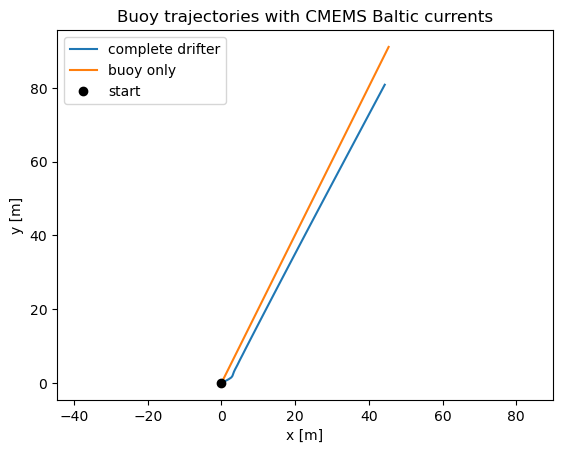

In [7]:
plt.plot(ds_complete.x, ds_complete.y, label="complete drifter")
plt.plot(ds_buoy.x, ds_buoy.y, label="buoy only")
plt.plot(0, 0, "ko", label="start")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.legend()
plt.title("Buoy trajectories with CMEMS Baltic currents")
plt.show()

## Tether angle

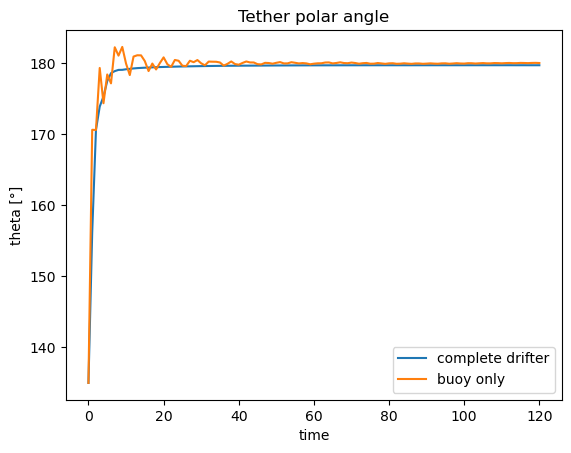

In [8]:
(ds_complete.theta * 180 / np.pi).plot(label="complete drifter")
(ds_buoy.theta * 180 / np.pi).plot(label="buoy only")
plt.ylabel("theta [°]")
plt.legend()
plt.title("Tether polar angle")
plt.show()